In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [ ]:
df = pd.read_csv('Demonstrativo_Normalizado.csv', sep=';', decimal=',', encoding='utf-8-sig')
df['Ano'] = df['Ano'].astype(int)
df['Cenario'] = df['Cenario'].astype(int)

print(f'Linhas: {df.shape[0]:,}  |  Colunas: {df.shape[1]}')
print(f'Anos: {sorted(df.Ano.unique())}')
print(f'Cenários simulados por ano: {df.Cenario.nunique()}')
df.head()

Linhas: 14,400  |  Colunas: 71
Anos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Cenários simulados por ano: 1200


,Ano,Cenario,BAL - Total do Ativo,BAL - Ativo Circulante,BAL - Disponível,BAL - Contas a Receber - SWAP,BAL - Contas a Receber - Partes Relacionadas,BAL - Contas a Receber - Clientes,BAL - Estoques Diversos,BAL - Outros Créditos,...,FLU - Custos,FLU - Investimentos,FLU - Entradas,FLU - Despesas Financeiras,FLU - Resultado Financeiro,FLU - Imposto de Renda e Contribuição Social,FLU - Distribuição para Acionista,FLU - Geração de Caixa,FLU - Saldo Final,BAL - Dividendos Antecipados
0,1,1,"10,631,127,075.26","1,795,720,872.18","1,205,264,965.52","95,680,421.92","584,661.47","453,870,957.15","86,620.79","40,233,245.33",...,"-761,637,166.56","-534,001,210.70","91,626,997.28","-822,031,381.44","-730,404,384.16","-934,472,751.30","-1,532,407,884.49","430,649,781.90","1,205,264,965.52",NaN
1,1,2,"10,623,913,756.08","1,789,812,253.20","1,198,930,875.29","96,105,893.18","584,661.47","453,870,957.15","86,620.79","40,233,245.33",...,"-759,943,240.90","-532,282,423.16","94,348,147.04","-820,028,485.02","-725,680,337.98","-931,256,706.16","-1,532,407,884.49","424,315,691.67","1,198,930,875.29",NaN
2,1,3,"10,623,167,968.07","1,790,756,413.98","1,195,791,531.74","100,189,397.51","584,661.47","453,870,957.15","86,620.79","40,233,245.33",...,"-757,939,761.48","-530,372,916.64","97,371,239.24","-805,754,754.73","-708,383,515.49","-930,403,973.49","-1,532,407,884.49","421,176,348.13","1,195,791,531.74",NaN
3,1,4,"10,623,286,492.97","1,791,311,489.63","1,196,227,922.70","100,308,082.20","584,661.47","453,870,957.15","86,620.79","40,233,245.33",...,"-757,525,899.77","-529,928,094.95","98,075,471.97","-803,137,516.19","-705,062,044.22","-930,690,314.04","-1,532,407,884.49","421,612,739.08","1,196,227,922.70",NaN
4,1,5,"10,601,794,070.01","1,770,573,971.33","1,179,899,365.07","95,899,121.53","584,661.47","453,870,957.15","86,620.79","40,233,245.33",...,"-755,720,338.52","-528,219,658.60","97,592,316.08","-820,751,229.98","-723,158,913.90","-921,363,480.74","-1,532,407,884.49","405,284,181.45","1,179,899,365.07",NaN


In [ ]:
KPIS = {
    'DRE - Receita': 'Receita',
    'DRE - EBITDA': 'EBITDA',
    'DRE - Resultado Líquido': 'Resultado Líquido',
    'FLU - Geração de Caixa': 'Geração de Caixa',
    'FLU - Saldo Final': 'Saldo Final de Caixa',
    'BAL - Total do Ativo': 'Total do Ativo',
}
list(KPIS.values())

['Receita',
 'EBITDA',
 'Resultado Líquido',
 'Geração de Caixa',
 'Saldo Final de Caixa',
 'Total do Ativo']

In [ ]:
def moda_por_faixa(serie, n_bins=20):
    """Divide a série em faixas (bins) de igual amplitude e retorna a faixa
    com maior número de ocorrências — a 'moda' de uma variável contínua."""
    contagem, bordas = np.histogram(serie.dropna(), bins=n_bins)
    i = contagem.argmax()
    return f'[{bordas[i]:,.0f} ; {bordas[i+1]:,.0f})'

linhas_posicao = []
for col, nome in KPIS.items():
    valores = df[col].dropna()
    linhas_posicao.append({
        'Indicador': nome,
        'Média': valores.mean(),
        'Mediana': valores.median(),
        'Moda (faixa mais frequente)': moda_por_faixa(valores),
    })

tabela_posicao = pd.DataFrame(linhas_posicao).set_index('Indicador')
tabela_posicao

,Média,Mediana,Moda (faixa mais frequente)
Indicador,,,
Receita,"7,913,424,292.75","7,336,983,920.54","[6,193,480,824 ; 6,635,381,974)"
EBITDA,"6,504,508,533.19","5,937,501,876.07","[4,792,101,531 ; 5,264,173,915)"
Resultado Líquido,"3,356,646,331.53","2,978,877,188.53","[2,311,581,762 ; 2,640,629,480)"
Geração de Caixa,"-27,920,002.76","163,143,487.66","[-222,039,236 ; 234,864,817)"
Saldo Final de Caixa,"1,135,679,831.41","1,088,177,961.16","[-12,601,992 ; 404,484,538)"
Total do Ativo,"7,629,177,166.80","7,528,454,837.06","[7,083,433,453 ; 7,692,186,650)"


In [ ]:
linhas_dispersao = []
for col, nome in KPIS.items():
    valores = df[col].dropna()
    variancia = valores.var(ddof=1)      # variância amostral (ddof=1)
    desvio = valores.std(ddof=1)         # desvio padrão amostral
    cv = desvio / abs(valores.mean()) if valores.mean() != 0 else np.nan
    linhas_dispersao.append({
        'Indicador': nome,
        'Variância': variancia,
        'Desvio Padrão': desvio,
        'CV agregado / ingênuo (%)': cv * 100,
    })

tabela_dispersao = pd.DataFrame(linhas_dispersao).set_index('Indicador')
tabela_dispersao

,Variância,Desvio Padrão,CV agregado / ingênuo (%)
Indicador,,,
Receita,"2,783,659,666,808,338,432.00","1,668,430,300.25",21.08
EBITDA,"3,293,554,101,516,968,960.00","1,814,815,170.07",27.90
Resultado Líquido,"1,776,101,367,107,276,288.00","1,332,704,531.06",39.70
Geração de Caixa,"838,836,277,775,383,296.00","915,880,056.44","3,280.37"
Saldo Final de Caixa,"725,780,618,556,014,336.00","851,927,589.97",75.01
Total do Ativo,"7,714,930,990,763,051,008.00","2,777,576,459.93",36.41


In [ ]:
cv_por_ano = pd.DataFrame({
    nome: (df.groupby('Ano')[col].std(ddof=1) / df.groupby('Ano')[col].mean().abs() * 100)
    for col, nome in KPIS.items()
})
cv_por_ano.index.name = 'Ano'

linhas_corrigidas = []
for col, nome in KPIS.items():
    serie_cv = cv_por_ano[nome]
    linhas_corrigidas.append({
        'Indicador': nome,
        'CV agregado / ingênuo (%)': tabela_dispersao.loc[nome, 'CV agregado / ingênuo (%)'],
        'CV mediano dentro do ano (%)': serie_cv.median(),
        'CV mín. entre os anos (%)': serie_cv.min(),
        'CV máx. entre os anos (%)': serie_cv.max(),
    })

tabela_dispersao_corrigida = pd.DataFrame(linhas_corrigidas).set_index('Indicador')
tabela_dispersao_corrigida.round(2)

,CV agregado / ingênuo (%),CV mediano dentro do ano (%),CV mín. entre os anos (%),CV máx. entre os anos (%)
Indicador,,,,
Receita,21.08,1.69,0.53,2.94
EBITDA,27.90,1.82,0.59,3.03
Resultado Líquido,39.70,2.96,1.88,4.06
Geração de Caixa,"3,280.37",40.86,8.71,193.20
Saldo Final de Caixa,75.01,32.94,16.34,79.85
Total do Ativo,36.41,1.78,0.43,"2,008.46"


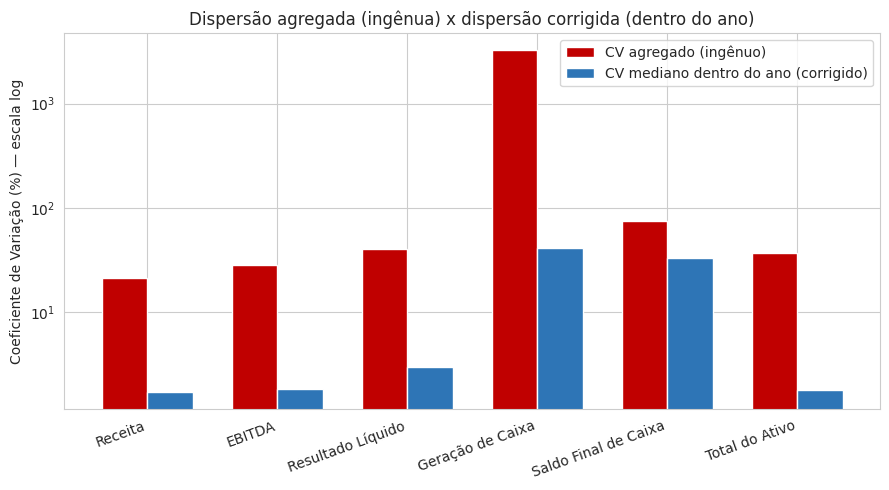

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(KPIS))
largura = 0.35

valores_agregado = tabela_dispersao_corrigida['CV agregado / ingênuo (%)'].values
valores_corrigido = tabela_dispersao_corrigida['CV mediano dentro do ano (%)'].values

# Geração de Caixa tem CV agregado tão alto (3.280%) que quebraria a escala do
# gráfico — usamos escala logarítmica no eixo Y só por causa desse ponto.
ax.bar(x - largura/2, valores_agregado, largura, label='CV agregado (ingênuo)', color='#C00000')
ax.bar(x + largura/2, valores_corrigido, largura, label='CV mediano dentro do ano (corrigido)', color='#2E75B6')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(tabela_dispersao_corrigida.index, rotation=20, ha='right')
ax.set_ylabel('Coeficiente de Variação (%) — escala log')
ax.set_title('Dispersão agregada (ingênua) x dispersão corrigida (dentro do ano)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
resumo_por_ano = (
    df.groupby('Ano')[list(KPIS.keys())]
      .agg(['mean', 'median', lambda s: s.std(ddof=1)])
)
resumo_por_ano.columns = [f'{KPIS[c]} - {"Desvio Padrão" if f=="<lambda_0>" else f.capitalize()}'
                           for c, f in resumo_por_ano.columns]
resumo_por_ano.round(0)

,Receita - Mean,Receita - Median,Receita - Desvio Padrão,EBITDA - Mean,EBITDA - Median,EBITDA - Desvio Padrão,Resultado Líquido - Mean,Resultado Líquido - Median,Resultado Líquido - Desvio Padrão,Geração de Caixa - Mean,Geração de Caixa - Median,Geração de Caixa - Desvio Padrão,Saldo Final de Caixa - Mean,Saldo Final de Caixa - Median,Saldo Final de Caixa - Desvio Padrão,Total do Ativo - Mean,Total do Ativo - Median,Total do Ativo - Desvio Padrão
Ano,,,,,,,,,,,,,,,,,,
1,"6,679,147,681.00","6,668,624,058.00","35,114,486.00","5,152,102,090.00","5,142,974,869.00","30,472,639.00","2,416,060,076.00","2,428,372,907.00","45,395,991.00","343,274,501.00","415,808,450.00","182,619,551.00","1,117,889,684.00","1,190,423,634.00","182,619,551.00","10,603,592,712.00","10,615,757,643.00","45,311,726.00"
2,"6,089,660,868.00","6,085,912,156.00","42,047,305.00","4,615,494,382.00","4,613,350,243.00","35,644,600.00","1,967,242,343.00","1,985,125,992.00","57,310,071.00","-240,349,139.00","-194,255,518.00","117,257,253.00","877,540,545.00","995,723,047.00","299,413,455.00","10,292,404,053.00","10,321,357,039.00","100,473,925.00"
3,"6,254,777,867.00","6,256,076,170.00","55,504,627.00","4,896,584,088.00","4,897,521,113.00","48,946,138.00","2,113,482,304.00","2,129,344,222.00","51,090,059.00","713,192,044.00","734,332,764.00","62,085,966.00","1,590,732,590.00","1,732,541,069.00","355,672,322.00","10,737,046,481.00","10,784,323,538.00","151,609,701.00"
4,"6,514,278,000.00","6,515,035,928.00","72,729,799.00","5,169,078,816.00","5,173,048,575.00","64,508,989.00","2,302,376,094.00","2,325,255,862.00","69,607,210.00","-624,309,929.00","-632,764,281.00","63,686,258.00","966,422,661.00","1,098,967,868.00","333,152,796.00","9,571,253,500.00","9,612,366,870.00","137,938,521.00"
5,"6,845,595,020.00","6,845,116,916.00","91,785,665.00","5,472,534,548.00","5,474,860,758.00","81,071,795.00","2,635,125,873.00","2,652,606,587.00","67,915,270.00","-709,802,441.00","-803,049,141.00","224,824,700.00","256,620,221.00","293,746,235.00","115,639,272.00","8,086,080,826.00","8,063,945,619.00","107,218,426.00"
6,"7,248,545,942.00","7,245,085,631.00","113,749,600.00","5,836,868,799.00","5,834,809,356.00","99,197,748.00","2,950,871,361.00","2,961,135,557.00","70,952,301.00","-21,791,931.00","-30,321,425.00","42,102,662.00","234,828,290.00","262,429,939.00","109,572,724.00","7,547,624,949.00","7,522,747,391.00","121,428,204.00"
7,"7,673,514,335.00","7,668,943,419.00","139,625,687.00","6,221,628,538.00","6,221,454,970.00","120,836,248.00","3,141,984,474.00","3,152,495,170.00","84,943,133.00","146,631,316.00","161,091,405.00","80,101,929.00","381,459,606.00","427,308,572.00","180,923,904.00","7,198,378,015.00","7,181,408,245.00","140,853,871.00"
8,"8,165,980,166.00","8,156,250,320.00","169,999,580.00","6,650,720,920.00","6,649,395,480.00","145,640,350.00","3,397,816,933.00","3,410,298,261.00","102,420,336.00","880,333,172.00","923,314,314.00","166,938,813.00","1,261,792,778.00","1,352,820,463.00","337,042,239.00","7,478,588,028.00","7,502,148,534.00","276,107,035.00"
9,"8,633,368,484.00","8,618,773,764.00","203,717,080.00","7,061,535,492.00","7,057,399,358.00","173,689,137.00","3,668,072,395.00","3,687,570,957.00","130,206,661.00","450,949,489.00","493,754,810.00","172,963,286.00","1,712,742,266.00","1,846,034,459.00","507,277,893.00","7,232,274,719.00","7,305,157,854.00","451,474,429.00"


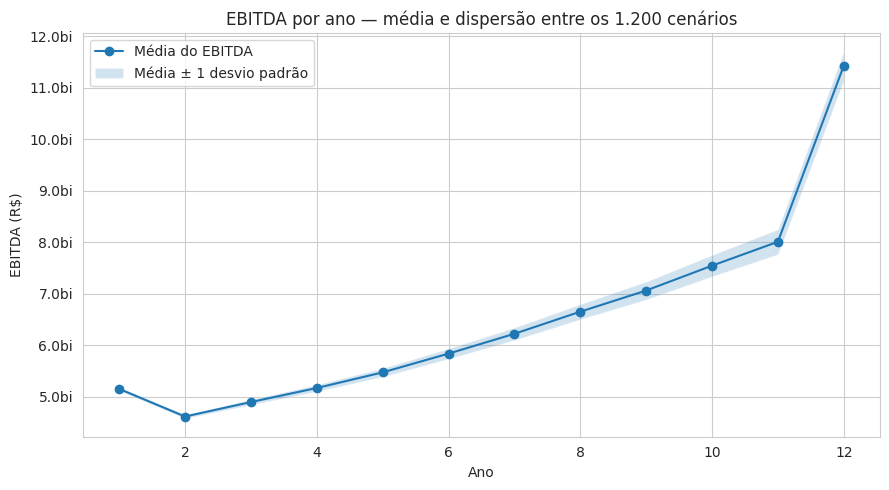

In [ ]:
# Gráfico de evolução: EBITDA (média e faixa +/- 1 desvio padrão) por ano
media_ebitda = df.groupby('Ano')['DRE - EBITDA'].mean()
desvio_ebitda = df.groupby('Ano')['DRE - EBITDA'].std(ddof=1)

plt.figure(figsize=(9, 5))
plt.plot(media_ebitda.index, media_ebitda.values, marker='o', label='Média do EBITDA')
plt.fill_between(media_ebitda.index, media_ebitda - desvio_ebitda, media_ebitda + desvio_ebitda,
                  alpha=0.2, label='Média ± 1 desvio padrão')
plt.title('EBITDA por ano — média e dispersão entre os 1.200 cenários')
plt.xlabel('Ano')
plt.ylabel('EBITDA (R$)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:,.1f}bi'))
plt.legend()
plt.tight_layout()
plt.show()

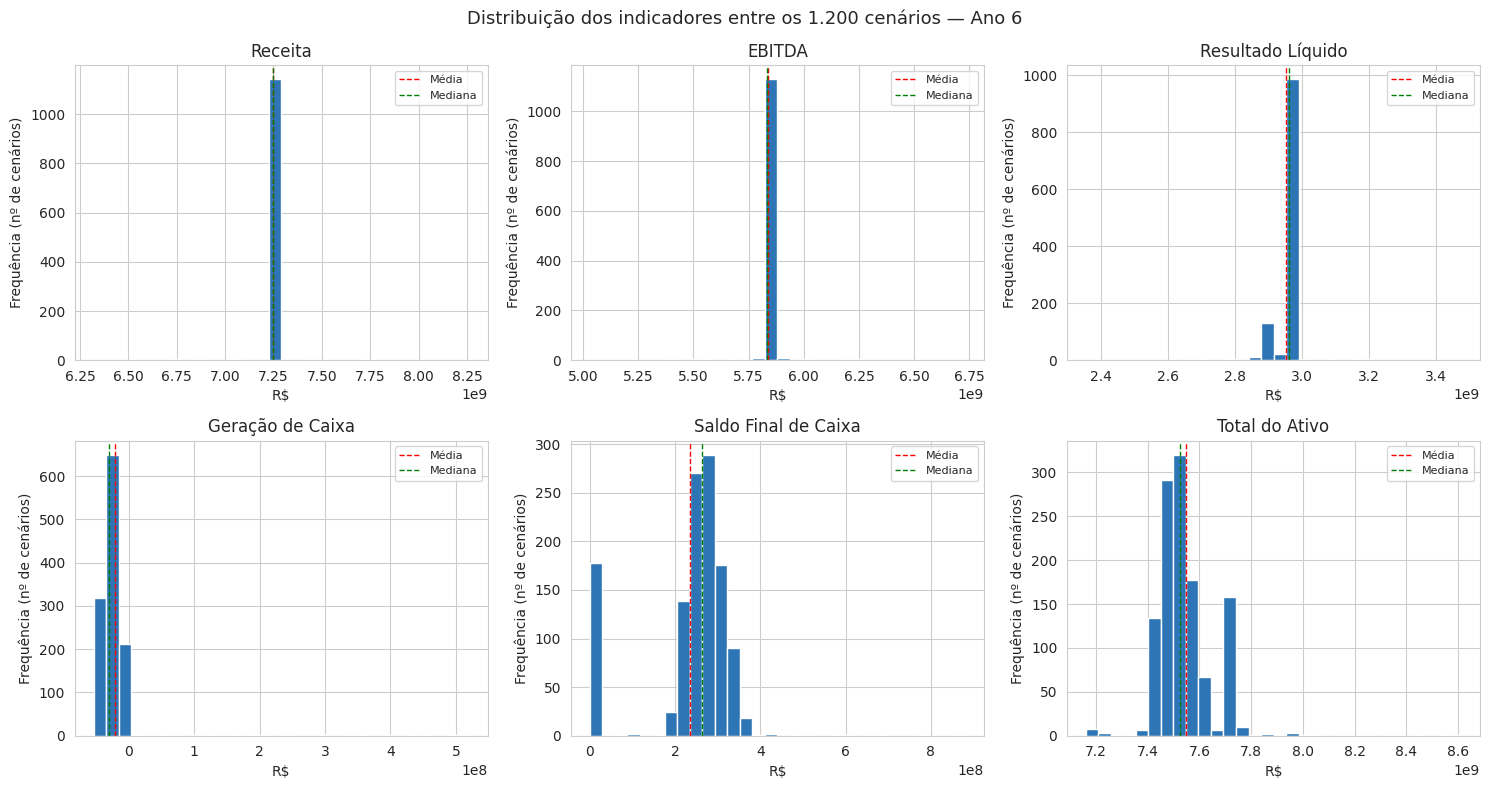

In [ ]:
ano_referencia = 6
sub = df[df['Ano'] == ano_referencia]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, nome) in zip(axes.flat, KPIS.items()):
    ax.hist(sub[col].dropna(), bins=30, color='#2E75B6', edgecolor='white')
    ax.axvline(sub[col].mean(), color='red', linestyle='--', linewidth=1, label='Média')
    ax.axvline(sub[col].median(), color='green', linestyle='--', linewidth=1, label='Mediana')
    ax.set_title(nome)
    ax.set_xlabel('R$')
    ax.set_ylabel('Frequência (nº de cenários)')
    ax.legend(fontsize=8)

fig.suptitle(f'Distribuição dos indicadores entre os 1.200 cenários — Ano {ano_referencia}', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_111/3863917808.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dados_por_ano, labels=sorted(df['Ano'].unique()), showmeans=True,
/tmp/ipykernel_111/3863917808.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dados_por_ano, labels=sorted(df['Ano'].unique()), showmeans=True,
/tmp/ipykernel_111/3863917808.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dados_por_ano, labels=sorted(df['Ano'].unique()), showmeans=True,
/tmp/ipykernel_111/3863917808.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotli

/tmp/ipykernel_111/3863917808.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dados_por_ano, labels=sorted(df['Ano'].unique()), showmeans=True,
/tmp/ipykernel_111/3863917808.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dados_por_ano, labels=sorted(df['Ano'].unique()), showmeans=True,


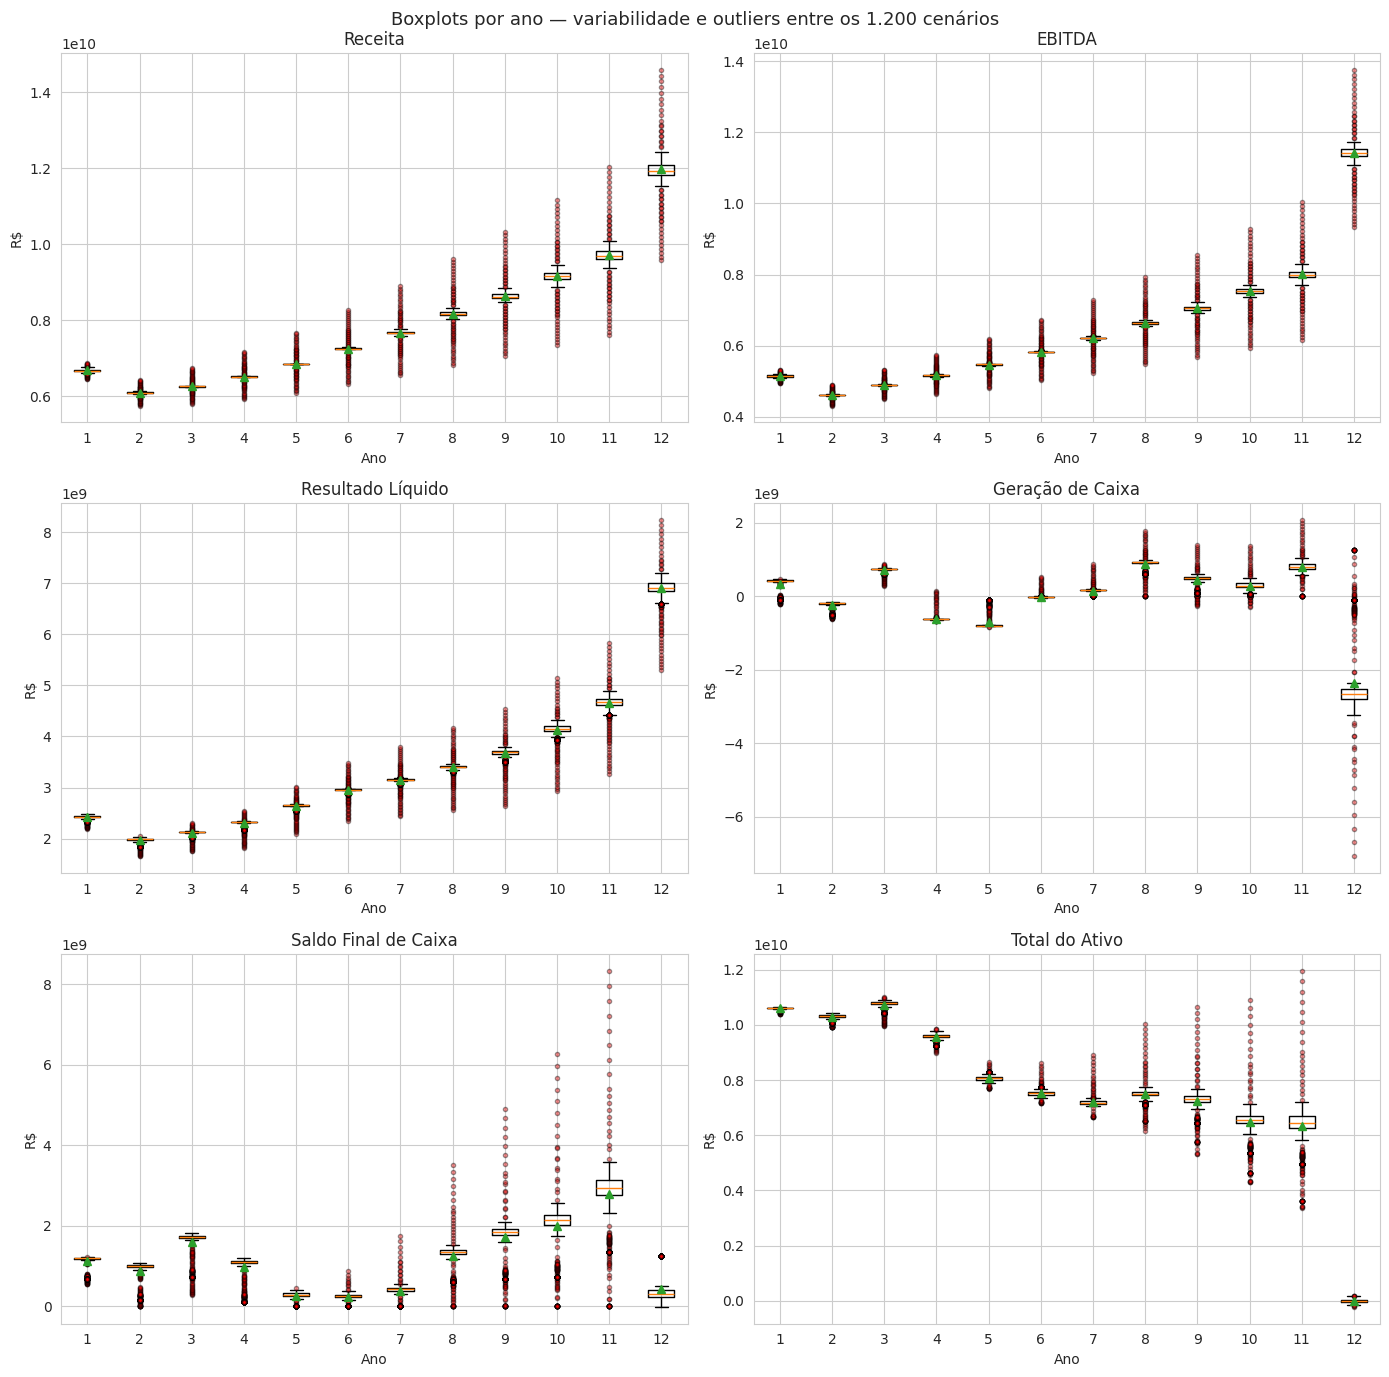

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, (col, nome) in zip(axes.flat, KPIS.items()):
    dados_por_ano = [df[df['Ano'] == a][col].dropna().values for a in sorted(df['Ano'].unique())]
    ax.boxplot(dados_por_ano, labels=sorted(df['Ano'].unique()), showmeans=True,
               flierprops=dict(marker='o', markersize=3, markerfacecolor='red', alpha=0.4))
    ax.set_title(nome)
    ax.set_xlabel('Ano')
    ax.set_ylabel('R$')

fig.suptitle('Boxplots por ano — variabilidade e outliers entre os 1.200 cenários', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def contar_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < limite_inf) | (serie > limite_sup)).sum()

linhas_outliers = []
for col, nome in KPIS.items():
    for ano in sorted(df['Ano'].unique()):
        serie = df[df['Ano'] == ano][col].dropna()
        n_out = contar_outliers(serie)
        if n_out > 0:
            linhas_outliers.append({'Indicador': nome, 'Ano': ano,
                                     'Nº de cenários atípicos': n_out,
                                     '% dos 1.200 cenários': round(n_out / len(serie) * 100, 2)})

tabela_outliers = pd.DataFrame(linhas_outliers)
tabela_outliers

,Indicador,Ano,Nº de cenários atípicos,% dos 1.200 cenários
0,Receita,1,32,2.67
1,Receita,2,50,4.17
2,Receita,3,104,8.67
3,Receita,4,68,5.67
4,Receita,5,76,6.33
...,...,...,...,...
67,Total do Ativo,8,190,15.83
68,Total do Ativo,9,193,16.08
69,Total do Ativo,10,191,15.92
70,Total do Ativo,11,191,15.92
